#### Importing Libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading the datasets

In [36]:
train_path = "../Data/raw/UNSW_NB15_training-set.csv"
test_path = "../Data/raw/UNSW_NB15_testing-set.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(df_train.head())
print(df_test.head())

   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
0                 0   

#### Exploratory Data Analysis (EDA)

In [37]:
print('Training Dataset Shape: ', df_train.shape)
print('Testing Dataset Shape: ', df_test.shape)

Training Dataset Shape:  (175341, 45)
Testing Dataset Shape:  (82332, 45)


In [38]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

In [39]:
df_train.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

No missing values in any column.

Class Distribution

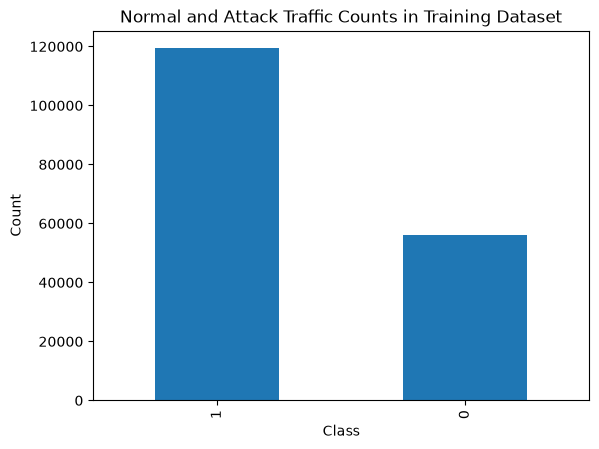

In [40]:
df_train['label'].value_counts().plot(kind='bar')

plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Normal and Attack Traffic Counts in Training Dataset')
plt.show()

Attack categories

In [41]:
df_train["attack_cat"].value_counts()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

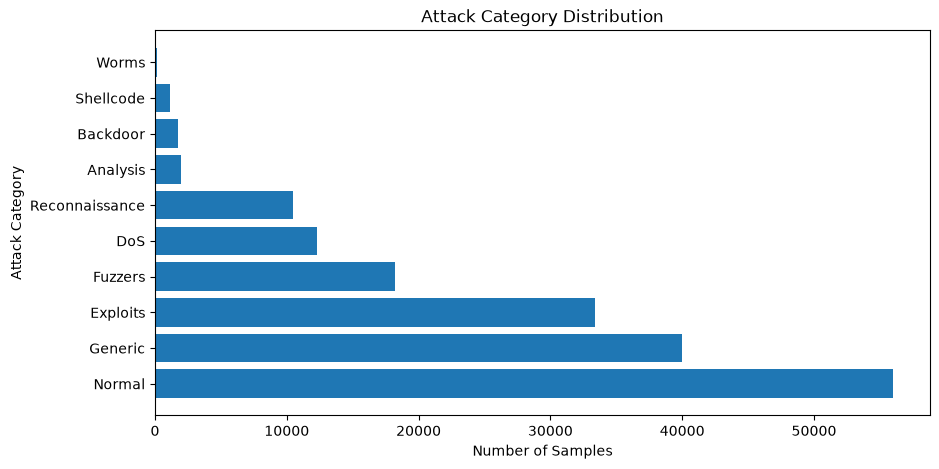

In [42]:
attack_counts = df_train["attack_cat"].value_counts()

plt.figure(figsize=(10,5))

plt.barh(
    attack_counts.index,
    attack_counts.values
)

plt.xlabel("Number of Samples")
plt.ylabel("Attack Category")
plt.title("Attack Category Distribution")

plt.show()

Check Correlation

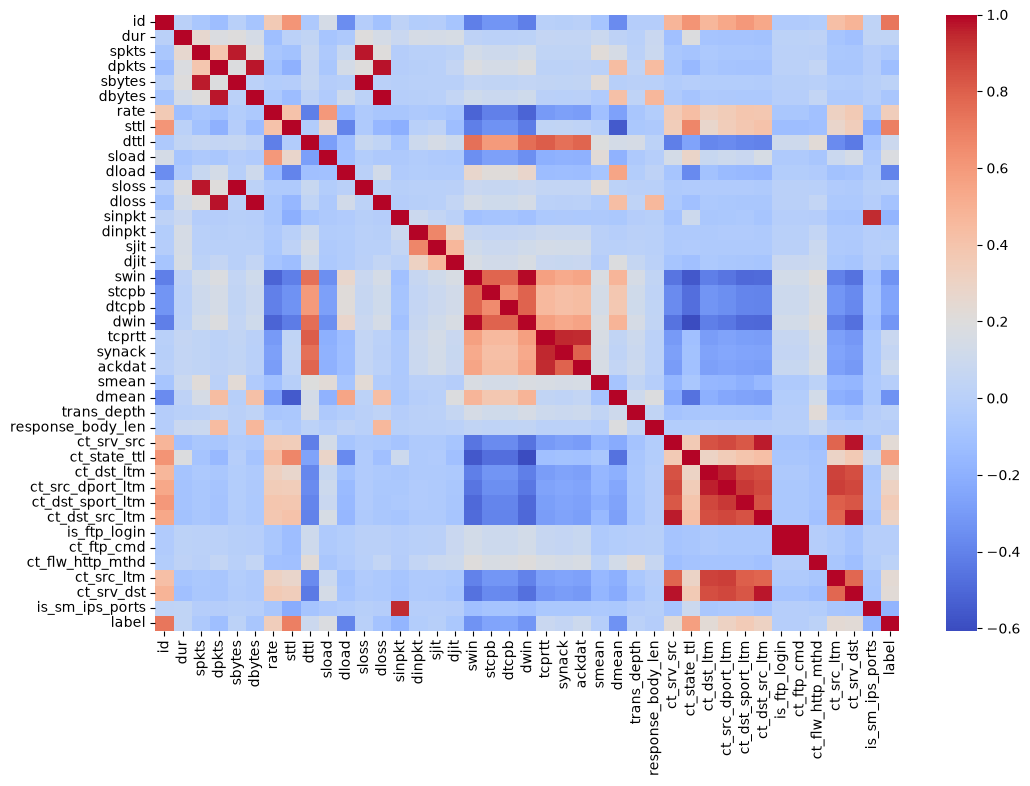

In [43]:
plt.figure(figsize=(12,8))
sns.heatmap(df_train.corr(numeric_only=True),cmap="coolwarm")

plt.show()

Finding columns that require encoding

In [44]:
df_train.select_dtypes(include="object").columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_9376\167698775.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.select_dtypes(include="object").columns


Index(['proto', 'service', 'state', 'attack_cat'], dtype='str')

#### EDA Findings

- Dataset contains 175,341 network traffic records.
- There are 44 features including numerical and categorical attributes.
- No missing values were detected.
- The dataset contains both normal and malicious traffic.
- Attack traffic represents approximately 68% of the training data.
- attack_cat will be removed for binary classification to prevent data leakage.
- Three categorical features (proto, service, state) require encoding.